In [1]:
import os
import random
import warnings
from collections import Counter
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from datasets import load_dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModel




DEBUG = False
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 45390

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Device: {device}")

Device: cuda


In [2]:
import sys
import subprocess
REPO_URL = "https://github.com/facebookresearch/ssl-data-curation.git"
PROJECT_PATH = os.path.abspath(os.path.join("."))
REPO_NAME = "ssl-data-curation"
REPO_PATH = os.path.join(PROJECT_PATH, f"{REPO_NAME}/")
def setup_repo():
    if not os.path.exists(REPO_PATH):
        print(f"--- Cloning repository {REPO_NAME}... ---")
        subprocess.run(["git", "clone", REPO_URL], check=True)

    src_path = os.path.join(REPO_PATH, "src")
    if src_path not in sys.path:
        sys.path.insert(0, src_path)
    if REPO_PATH not in sys.path:
        sys.path.insert(0, REPO_PATH)
    print("--- Repository paths configured ---")
    
setup_repo()
from src.clusters import HierarchicalCluster
from src import hierarchical_kmeans_gpu as hkmg
from src import hierarchical_sampling as hs


--- Repository paths configured ---


In [3]:

resnet_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

dino_processor = AutoImageProcessor.from_pretrained('facebook/dinov2-large')

def apply_dino_transform(examples):
    images = [img.convert('RGB') if img.mode != 'RGB' else img for img in examples['image']]
    examples['pixel_values'] = [dino_processor(images=img, return_tensors="pt")["pixel_values"].squeeze(0) for img in images]
    return examples

def apply_resnet_transform(examples):
    images = [img.convert('RGB') if img.mode != 'RGB' else img for img in examples['image']]
    examples['pixel_values'] = [resnet_transform(img) for img in images]
    return examples

print("Pobieranie zbioru inria-chile/imagenet-lt-v2...")
dataset = load_dataset("inria-chile/imagenet-lt-v2")
NUM_CLASSES = 1000

train_dataset_resnet = dataset["train"].with_transform(apply_resnet_transform)
train_dataset_dino = dataset["train"].with_transform(apply_dino_transform)

val_dataset_resnet = dataset["val"].with_transform(apply_resnet_transform)
val_dataset_dino = dataset["val"].with_transform(apply_dino_transform)

test_dataset_resnet = dataset["test"].with_transform(apply_resnet_transform)
test_dataset_dino = dataset["test"].with_transform(apply_dino_transform)

def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.tensor([item['label'] for item in batch])
    return pixel_values, labels

batch_size = 128

Pobieranie zbioru inria-chile/imagenet-lt-v2...


Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/27 [00:00<?, ?it/s]

In [11]:
import torch.nn.functional as F

def load_resnet50_places365(device):

    model = models.resnet50(num_classes=365)

    url = "http://places2.csail.mit.edu/models_places365/resnet50_places365.pth.tar"
    checkpoint = torch.hub.load_state_dict_from_url(url, map_location="cpu")

    state_dict = {k.replace('module.', ''): v for k, v in checkpoint['state_dict'].items()}
    model.load_state_dict(state_dict)

    model.fc = nn.Identity()
    for param in model.parameters():
        param.requires_grad = False
        
    return model.eval().to(device)

def extract_features(hf_dataset, extractor, desc):
    all_features = []
    loader = DataLoader(hf_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    with torch.inference_mode(), torch.amp.autocast("cuda" if torch.cuda.is_available() else "cpu"):
        for imgs, _ in tqdm(loader, desc=desc):
            feat = extractor(imgs.to(device))
            if hasattr(feat, 'last_hidden_state'):
                feat = feat.last_hidden_state[:, 0, :]
            all_features.append(feat.cpu())

    return torch.cat(all_features).float().to(device)

In [3]:

resnet_extractor = load_resnet50_places365(device)
dino_extractor = AutoModel.from_pretrained('facebook/dinov2-large').eval().to(device)
for p in dino_extractor.parameters(): p.requires_grad = False

print("\n--- Ekstrakcja cech ResNet50-Places365 ---")
train_resnet_emb = extract_features(train_dataset_resnet, resnet_extractor, "Train ResNet50")
val_resnet_emb = extract_features(val_dataset_resnet, resnet_extractor, "Val ResNet50")
test_resnet_emb = extract_features(test_dataset_resnet, resnet_extractor, "Test ResNet50")

print("\n--- Ekstrakcja cech DINOv2 ---")
train_dino_emb = extract_features(train_dataset_dino, dino_extractor, "Train DINO")
val_dino_emb = extract_features(val_dataset_dino, dino_extractor, "Val DINO")
test_dino_emb = extract_features(test_dataset_dino, dino_extractor, "Test DINO")

print("\n--- Normalizacja L2 dla wszystkich embeddingów ---")
train_resnet_emb = F.normalize(train_resnet_emb, p=2, dim=1)
val_resnet_emb = F.normalize(val_resnet_emb, p=2, dim=1)
test_resnet_emb = F.normalize(test_resnet_emb, p=2, dim=1)

train_dino_emb = F.normalize(train_dino_emb, p=2, dim=1)
val_dino_emb = F.normalize(val_dino_emb, p=2, dim=1)
test_dino_emb = F.normalize(test_dino_emb, p=2, dim=1)

print("Gotowe! Można klastrować i trenować.")




Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]


--- Ekstrakcja cech ResNet50-Places365 ---


NameError: name 'train_dataset_resnet' is not defined

In [ ]:
import torch

embeddings_dict = {
    'train_resnet': train_resnet_emb.cpu(),
    'val_resnet': val_resnet_emb.cpu(),
    'test_resnet': test_resnet_emb.cpu(),
    'train_dino': train_dino_emb.cpu(),
    'val_dino': val_dino_emb.cpu(),
    'test_dino': test_dino_emb.cpu()
}

file_path = 'embeddings_places_dino.pt'
torch.save(embeddings_dict, file_path)

print(f"Wszystkie embeddingi zostały zapisane w pliku: {file_path}")

In [4]:
import torch

file_path = 'embeddings_places_dino.pt'

loaded_embeddings = torch.load(file_path, map_location=device)

train_resnet_emb = loaded_embeddings['train_resnet']
val_resnet_emb = loaded_embeddings['val_resnet']
test_resnet_emb = loaded_embeddings['test_resnet']

train_dino_emb = loaded_embeddings['train_dino']
val_dino_emb = loaded_embeddings['val_dino']
test_dino_emb = loaded_embeddings['test_dino']

print("Embeddingi zostały pomyślnie wczytane!")
print(f"Rozmiar train ResNet: {train_resnet_emb.shape}")
print(f"Rozmiar train DINO: {train_dino_emb.shape}")

Embeddingi zostały pomyślnie wczytane!
Rozmiar train ResNet: torch.Size([115846, 2048])
Rozmiar train DINO: torch.Size([115846, 1024])


In [5]:
def get_labels_safely(hf_dataset):
    labels = []
    for batch in hf_dataset.select_columns("label").iter(batch_size=1000):
        labels.extend(batch["label"])
    return torch.tensor(labels)

print("Wyciąganie etykiet (w trybie awaryjnym)...")
train_labels = get_labels_safely(dataset["train"])
val_labels = get_labels_safely(dataset["val"])
test_labels = get_labels_safely(dataset["test"])
print("Etykiety pobrane pomyślnie!")


Wyciąganie etykiet (w trybie awaryjnym)...
Etykiety pobrane pomyślnie!


In [6]:
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import torch.optim as optim
batch_size=512
def train_linear_probing(x_train, y_train, x_val, y_val, x_test, y_test, title, max_epochs=40, patience=5):
    train_loader = DataLoader(torch.utils.data.TensorDataset(x_train, y_train), batch_size=512, shuffle=True)
    val_loader = DataLoader(torch.utils.data.TensorDataset(x_val, y_val), batch_size=512, shuffle=False)
    test_loader = DataLoader(torch.utils.data.TensorDataset(x_test, y_test), batch_size=512, shuffle=False)
    
    in_features = x_train.shape[1]
    

    model = nn.Sequential(
        nn.Dropout(p=0.3),
        nn.Linear(in_features, NUM_CLASSES)
    ).to(device)
    

    classes_present = torch.unique(y_train).cpu().numpy()
    y_train_np = y_train.cpu().numpy()
    weights = compute_class_weight(class_weight='balanced', classes=classes_present, y=y_train_np)
    
    class_weights = torch.ones(NUM_CLASSES).to(device)
    for c, w in zip(classes_present, weights):
        class_weights[c] = w
        
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    
    optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
    
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    best_val_loss = float('inf')
    best_state = None
    patience_counter = 0
    
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    
    for epoch in range(max_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * x.size(0)
            _, predicted = torch.max(outputs.data, 1)
            train_total += y.size(0)
            train_correct += (predicted == y).sum().item()
            
        train_loss /= train_total
        train_acc = 100 * train_correct / train_total
            
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                outputs = model(x)
                loss = criterion(outputs, y)
                
                val_loss += loss.item() * x.size(0)
                _, predicted = torch.max(outputs.data, 1)
                val_total += y.size(0)
                val_correct += (predicted == y).sum().item()
        
        val_loss /= val_total
        val_acc = 100 * val_correct / val_total
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
    
                break
                
    model.load_state_dict(best_state)
    model.eval()
    
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)
            outputs = model(x)
            _, predicted = torch.max(outputs.data, 1)
            test_total += y.size(0)
            test_correct += (predicted == y).sum().item()
            
    test_acc = 100 * test_correct / test_total
    
    return test_acc, history

In [9]:
percentages = list(range(10, 101, 10))
results_resnet, results_dino = [], []
history_resnet, history_dino = {}, {}

learning_curves_resnet = {}
learning_curves_dino = {}

total_train_samples = len(train_labels)

N_CLUSTERS = [20, 10, 5]
N_LEVELS = 3

for p in percentages:
    print(f"\n{'='*40}\nEksperyment: {p}% danych treningowych\n{'='*40}")
    num_samples = int(total_train_samples * (p / 100.0))
    
    if p == 100:
        idx_res = list(range(total_train_samples))
        idx_din = list(range(total_train_samples))
    else:
        sz = [max(1, int(num_samples / n)) for n in N_CLUSTERS]

        set_seed(SEED)
        c_res = hkmg.hierarchical_kmeans_with_resampling(
            data=train_resnet_emb.float(), n_clusters=N_CLUSTERS, n_levels=N_LEVELS, sample_sizes=sz, verbose=False
        )

        cluster_obj_res = HierarchicalCluster.from_dict(c_res)

        idx_res = hs.hierarchical_sampling(
            clusters=cluster_obj_res, 
            target_size=num_samples, 
            sampling_strategy="c"
        ).astype(int).tolist()


        set_seed(SEED)
        c_din = hkmg.hierarchical_kmeans_with_resampling(
            data=train_dino_emb.float(), n_clusters=N_CLUSTERS, n_levels=N_LEVELS, sample_sizes=sz, verbose=False
        )

        cluster_obj_din = HierarchicalCluster.from_dict(c_din)


        idx_din = hs.hierarchical_sampling(
            clusters=cluster_obj_din, 
            target_size=num_samples, 
            sampling_strategy="c"
        ).astype(int).tolist()

    history_resnet[p] = idx_res
    history_dino[p] = idx_din
    

    acc_resnet, curves_resnet = train_linear_probing(
        train_resnet_emb[idx_res].float(), train_labels[idx_res],
        val_resnet_emb.float(), val_labels,
        test_resnet_emb.float(), test_labels, f"ResNet {p}%"
    )
    
    acc_dino, curves_dino = train_linear_probing(
        train_dino_emb[idx_din].float(), train_labels[idx_din],
        val_dino_emb.float(), val_labels,
        test_dino_emb.float(), test_labels, f"DINO {p}%"
    )
    results_resnet.append(acc_resnet)
    results_dino.append(acc_dino)
    
    learning_curves_resnet[p] = curves_resnet
    learning_curves_dino[p] = curves_dino
    
    print(f"ResNet-50 (Places365): {acc_resnet:.2f}% | DINO: {acc_dino:.2f}%")


Eksperyment: 10% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<?, ?it/s]
ResNet-50 (Places365): 9.00% | DINO: 19.21%

Eksperyment: 20% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<?, ?it/s]
ResNet-50 (Places365): 11.62% | DINO: 16.93%

Eksperyment: 30% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 484.40it/s]
ResNet-50 (Places365): 13.24% | DINO: 29.34%

Eksperyment: 40% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 2856.38it/s]
ResNet-50 (Places365): 13.69% | DINO: 58.60%

Eksperyment: 50% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 2486.54it/s]
ResNet-50 (Places365): 12.66% | DINO: 52.65%

Eksperyment: 60% danych treningowych
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 1654.17it/s]
ResNet-50 (Places365): 14.39% | DINO: 60.29%

Eksperyment: 

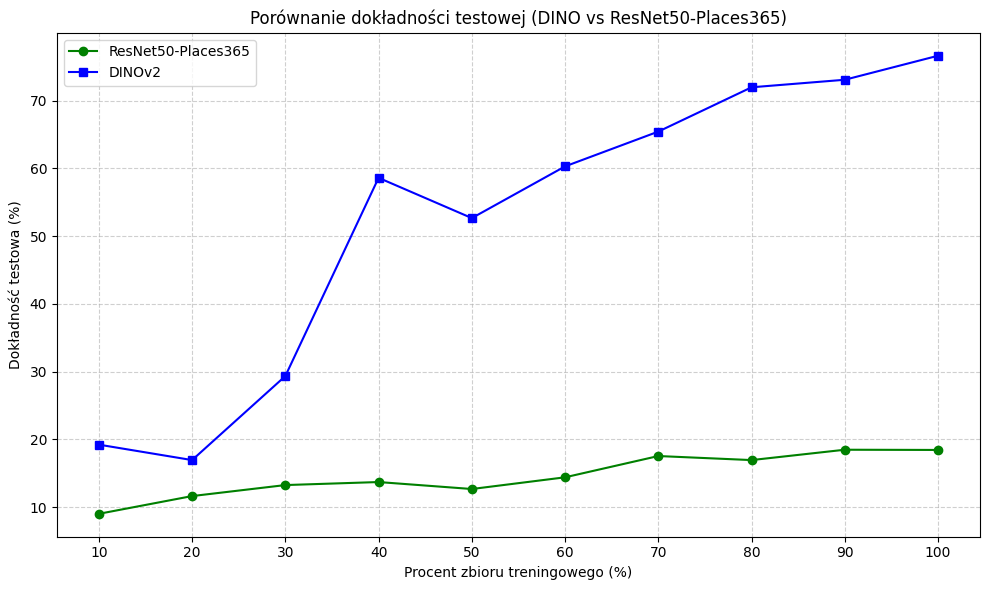

In [10]:
import os
import matplotlib.pyplot as plt
from collections import Counter


os.makedirs('plots', exist_ok=True)


plt.figure(figsize=(10, 6))
plt.plot(percentages, results_resnet, marker='o', color='green', label='ResNet50-Places365')
plt.plot(percentages, results_dino, marker='s', color='blue', label='DINOv2')
plt.title('Porównanie dokładności testowej (DINO vs ResNet50-Places365)')
plt.xlabel('Procent zbioru treningowego (%)')
plt.ylabel('Dokładność testowa (%)')
plt.xticks(percentages)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()


plt.savefig('plots/accuracy_comparison.png', dpi=300)
plt.show()



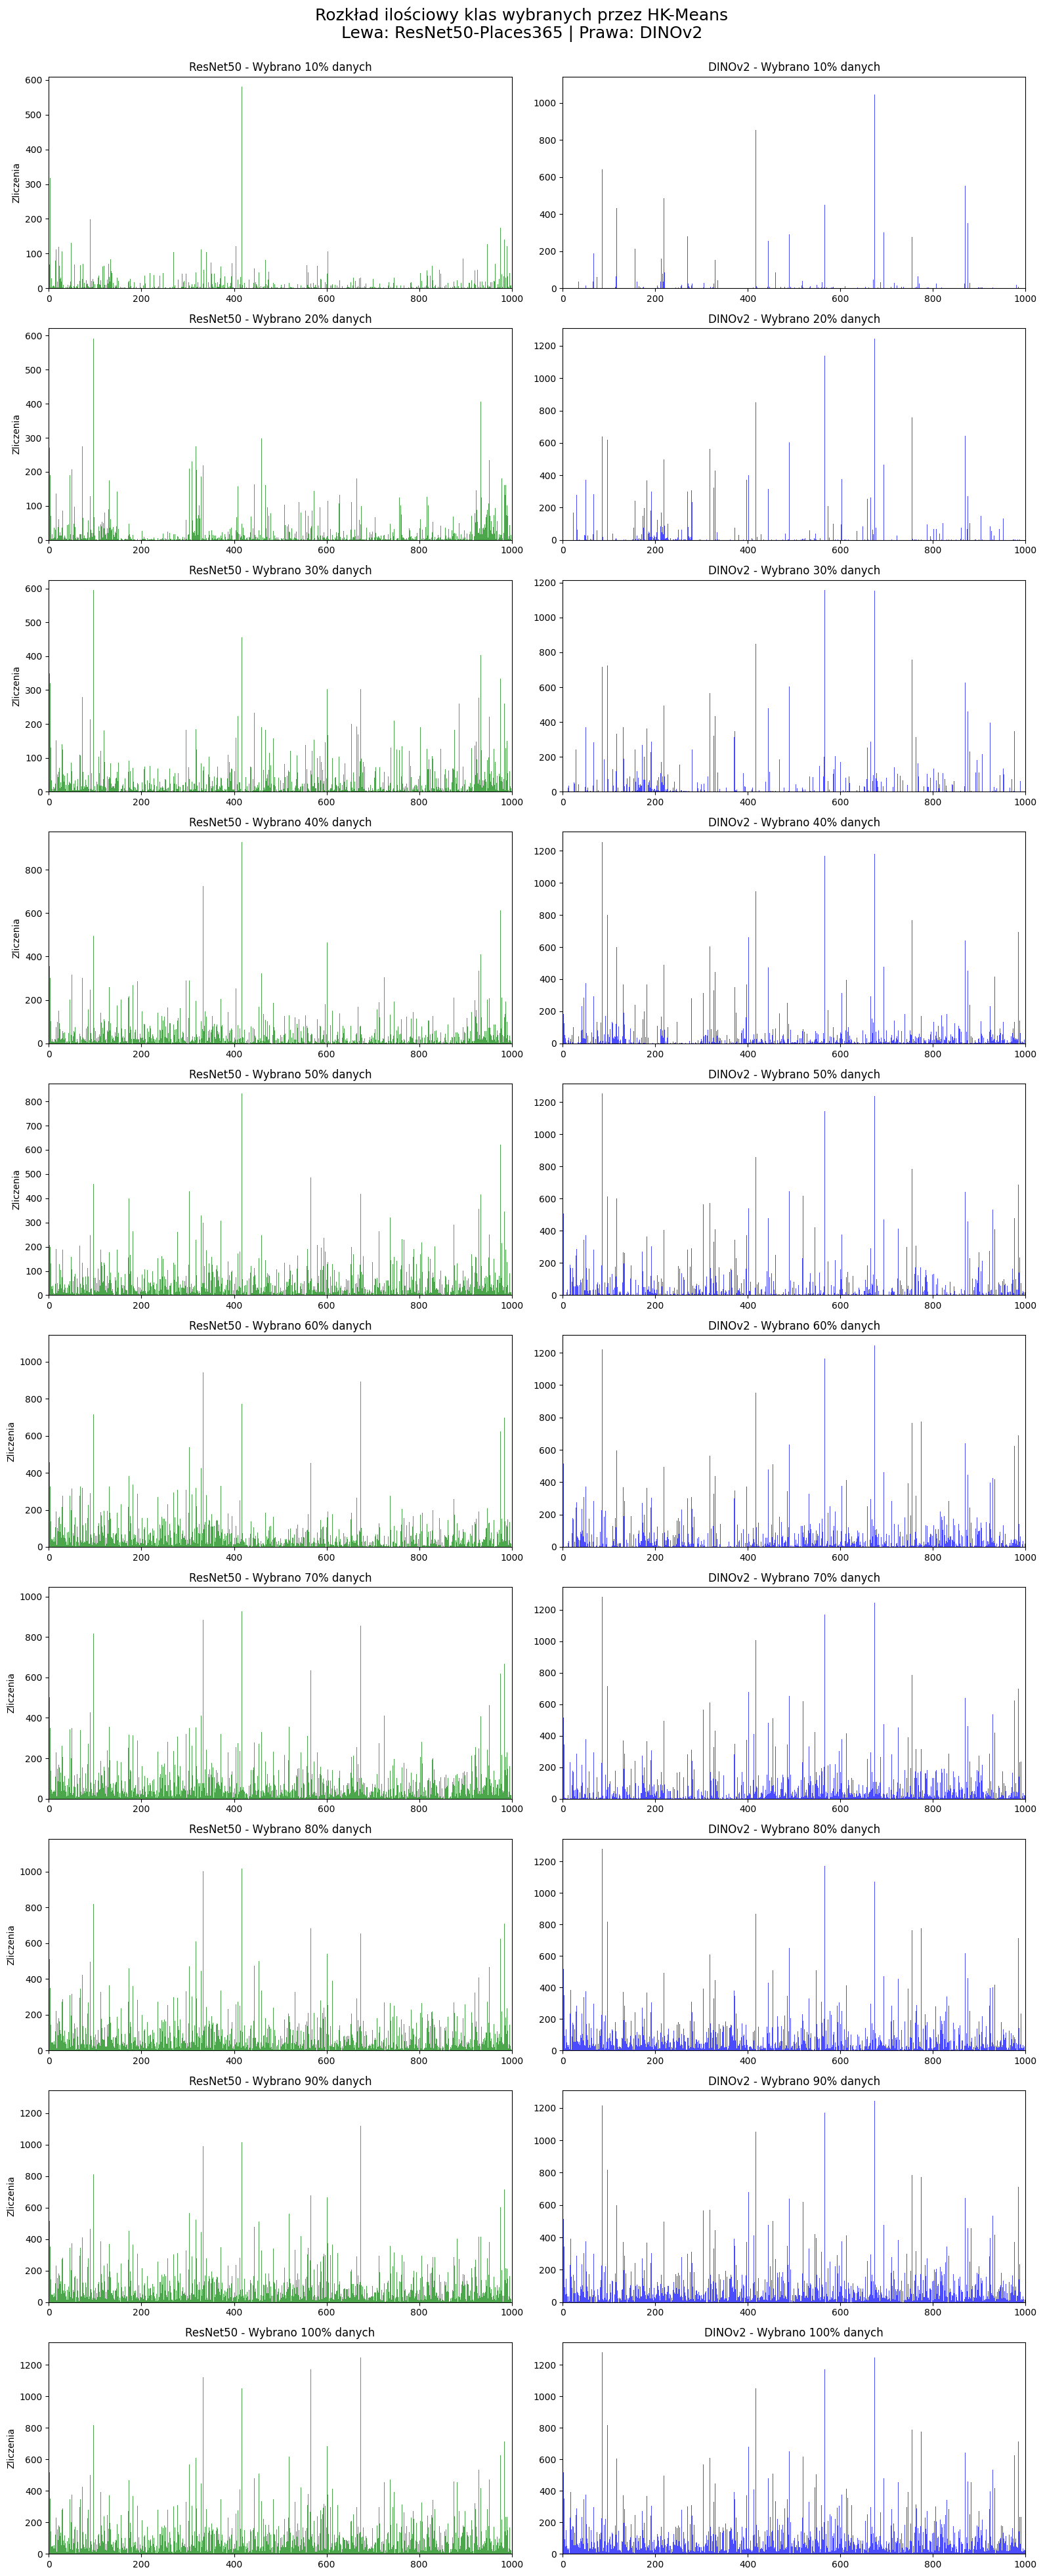

In [11]:

fig, axes = plt.subplots(len(percentages), 2, figsize=(16, 4 * len(percentages)))
fig.suptitle("Rozkład ilościowy klas wybranych przez HK-Means\nLewa: ResNet50-Places365 | Prawa: DINOv2", fontsize=18)

for i, p in enumerate(percentages):

    labels_res = [train_labels[idx].item() for idx in history_resnet[p]]
    counts_res = Counter(labels_res)
    ax_res = axes[i, 0] if len(percentages) > 1 else axes[0]
    ax_res.bar(counts_res.keys(), counts_res.values(), width=1.0, color='green', alpha=0.7)
    ax_res.set_title(f"ResNet50 - Wybrano {p}% danych")
    ax_res.set_ylabel("Zliczenia")
    ax_res.set_xlim(0, NUM_CLASSES)
    

    labels_din = [train_labels[idx].item() for idx in history_dino[p]]
    counts_din = Counter(labels_din)
    ax_din = axes[i, 1] if len(percentages) > 1 else axes[1]
    ax_din.bar(counts_din.keys(), counts_din.values(), width=1.0, color='blue', alpha=0.7)
    ax_din.set_title(f"DINOv2 - Wybrano {p}% danych")
    ax_din.set_xlim(0, NUM_CLASSES)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig('plots/class_distribution.png', dpi=300)
plt.show()

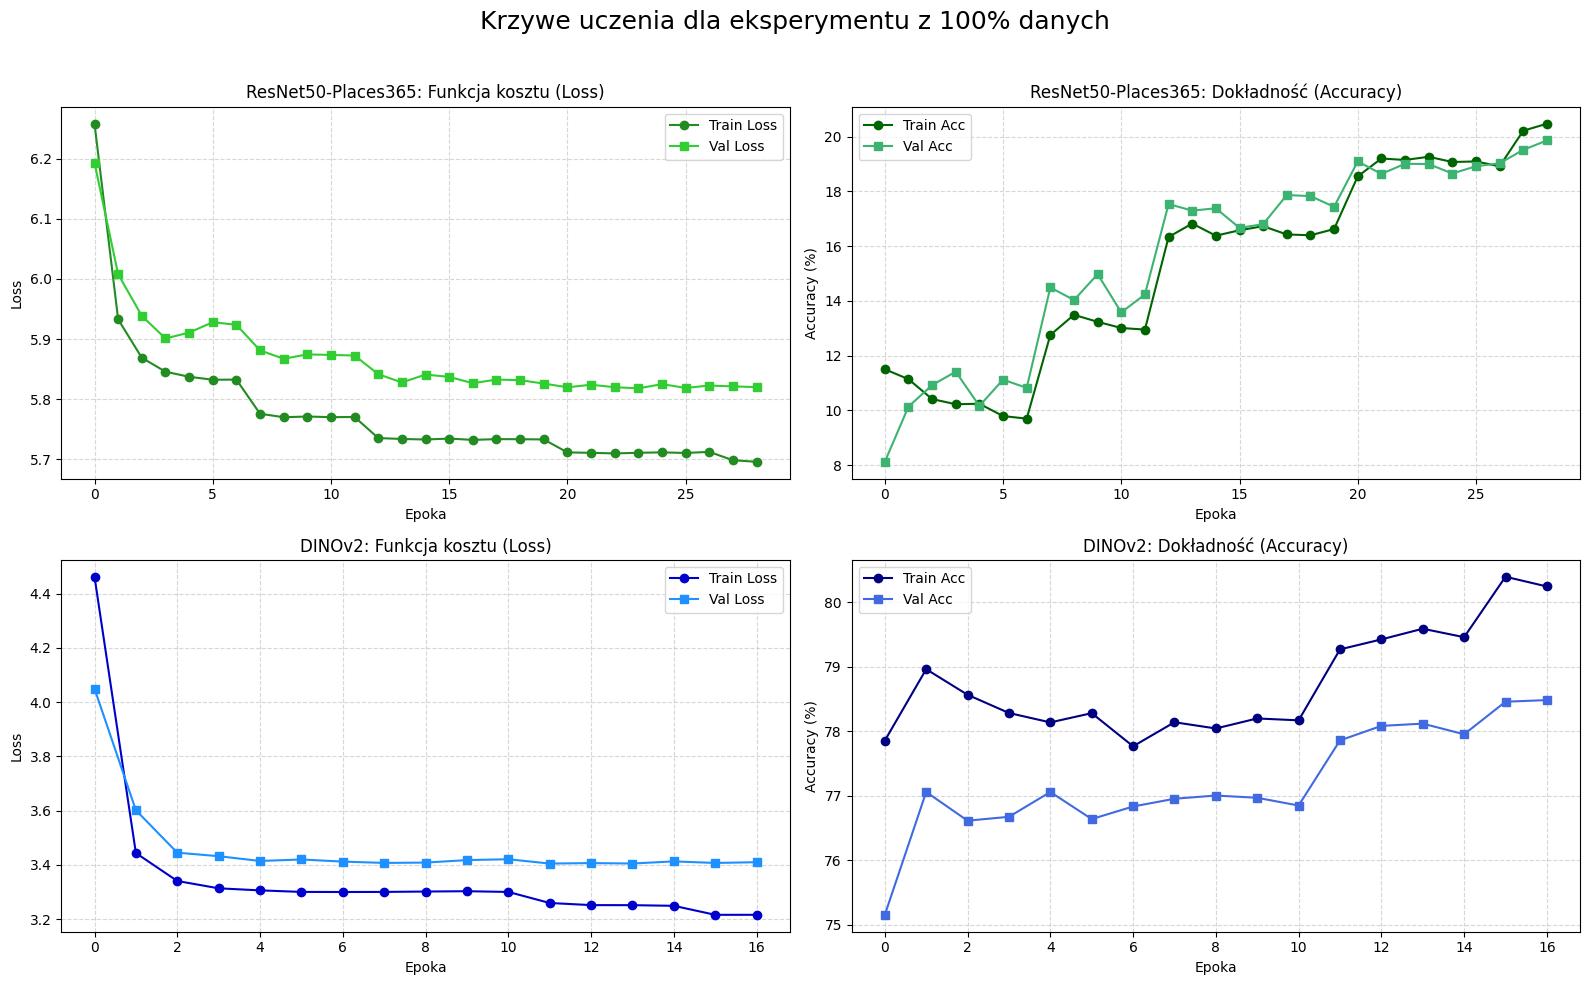

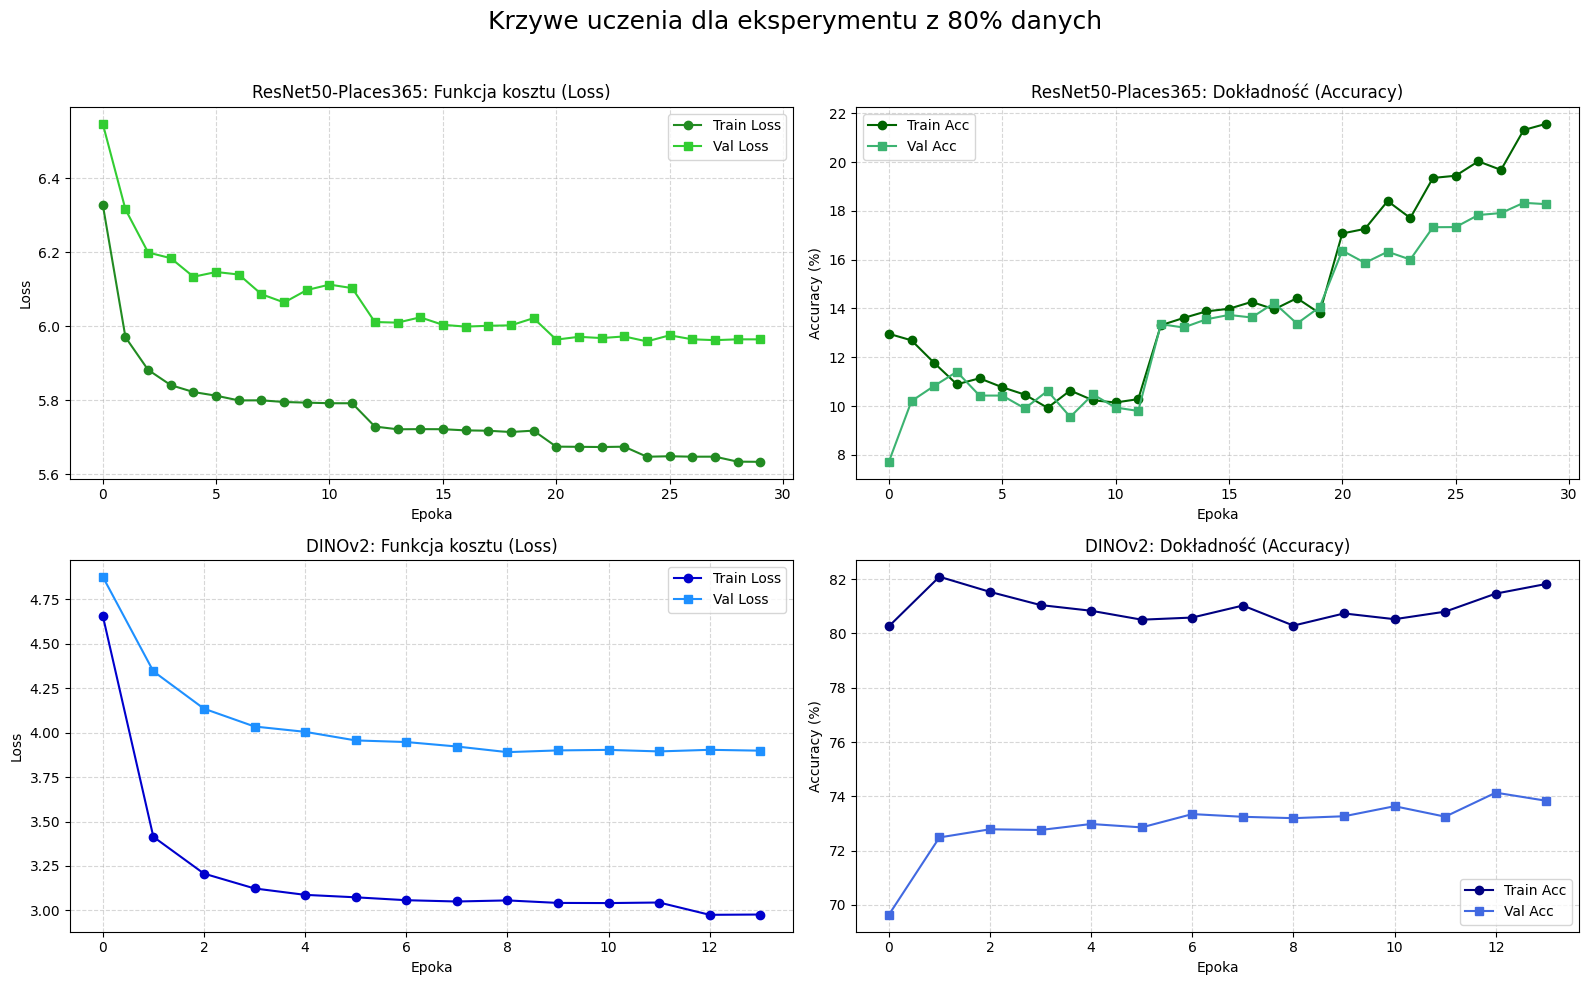

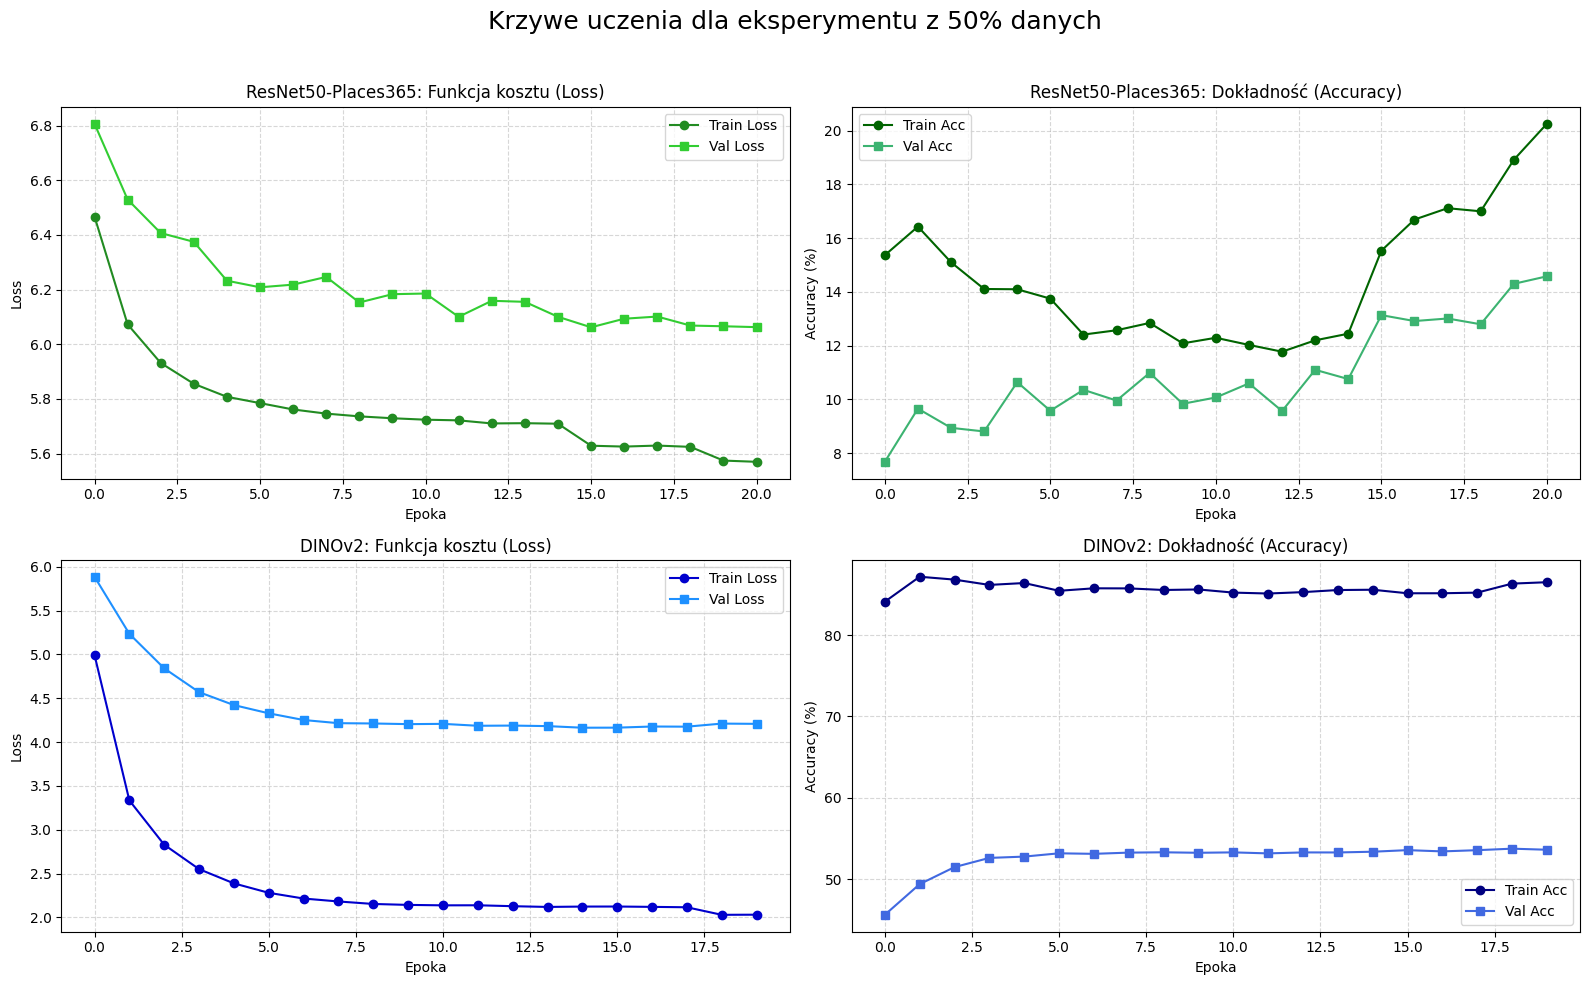

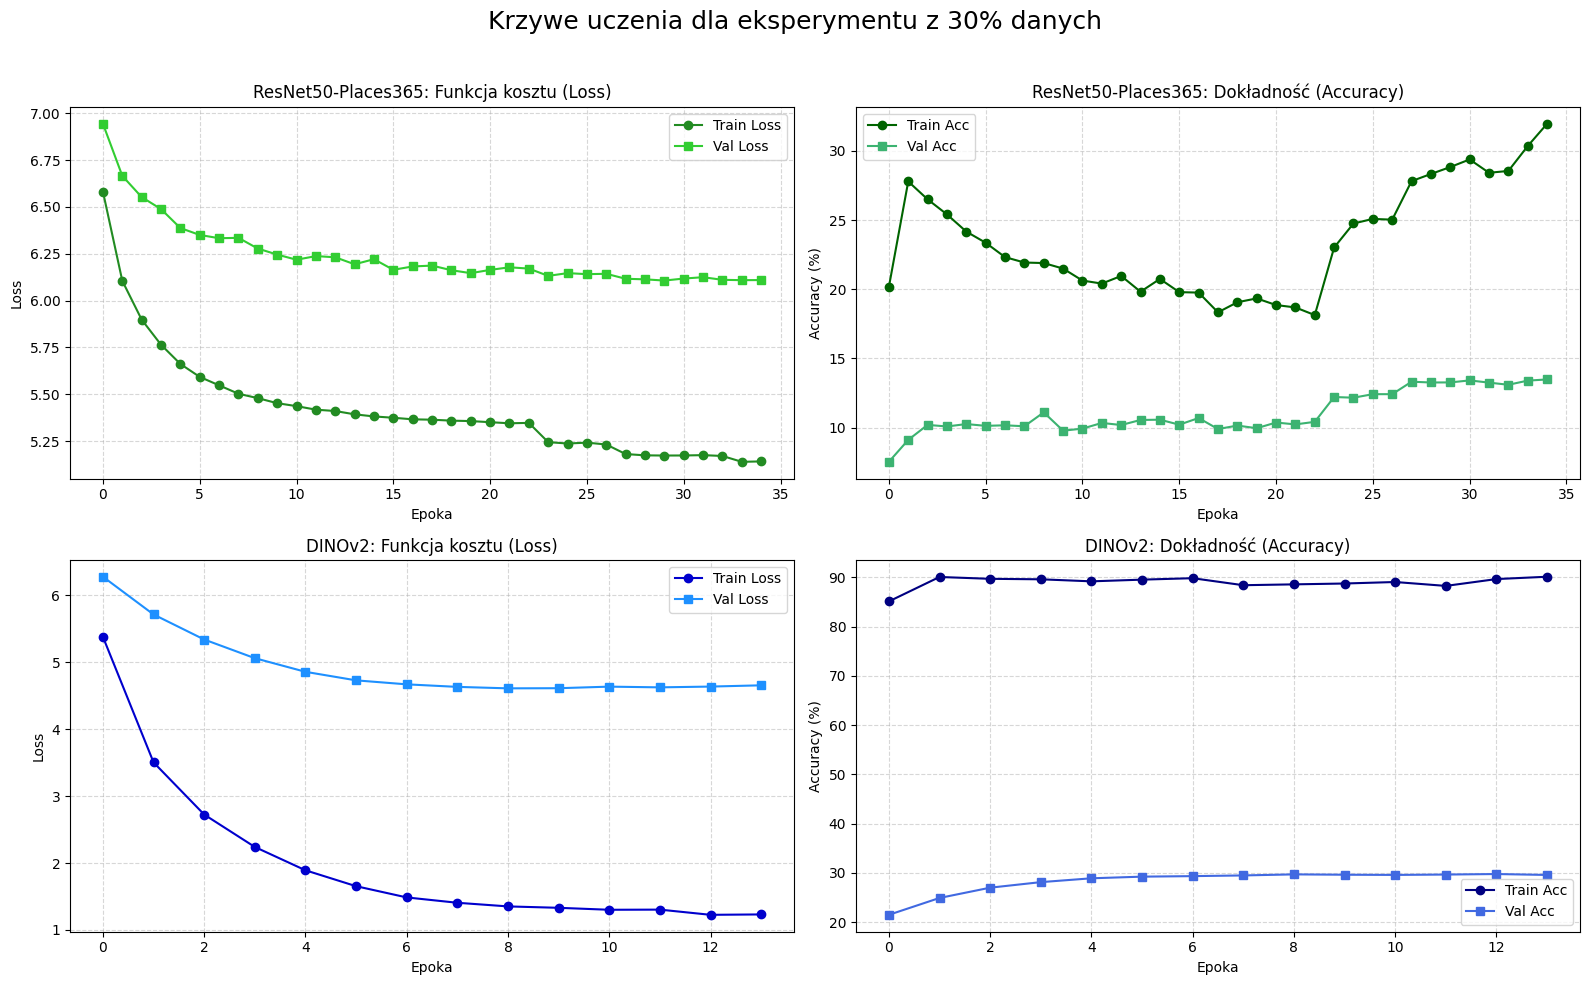

In [12]:
import os

def plot_learning_curves(curves_res, curves_din, percentage):
    os.makedirs('plots', exist_ok=True)
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f"Krzywe uczenia dla eksperymentu z {percentage}% danych", fontsize=18)

    axes[0, 0].plot(curves_res['train_loss'], label='Train Loss', marker='o', color='forestgreen')
    axes[0, 0].plot(curves_res['val_loss'], label='Val Loss', marker='s', color='limegreen')
    axes[0, 0].set_title('ResNet50-Places365: Funkcja kosztu (Loss)')
    axes[0, 0].set_xlabel('Epoka')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.5)

    axes[0, 1].plot(curves_res['train_acc'], label='Train Acc', marker='o', color='darkgreen')
    axes[0, 1].plot(curves_res['val_acc'], label='Val Acc', marker='s', color='mediumseagreen')
    axes[0, 1].set_title('ResNet50-Places365: Dokładność (Accuracy)')
    axes[0, 1].set_xlabel('Epoka')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, linestyle='--', alpha=0.5)

    axes[1, 0].plot(curves_din['train_loss'], label='Train Loss', marker='o', color='mediumblue')
    axes[1, 0].plot(curves_din['val_loss'], label='Val Loss', marker='s', color='dodgerblue')
    axes[1, 0].set_title('DINOv2: Funkcja kosztu (Loss)')
    axes[1, 0].set_xlabel('Epoka')
    axes[1, 0].set_ylabel('Loss')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)

    axes[1, 1].plot(curves_din['train_acc'], label='Train Acc', marker='o', color='navy')
    axes[1, 1].plot(curves_din['val_acc'], label='Val Acc', marker='s', color='royalblue')
    axes[1, 1].set_title('DINOv2: Dokładność (Accuracy)')
    axes[1, 1].set_xlabel('Epoka')
    axes[1, 1].set_ylabel('Accuracy (%)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.savefig(f'plots/learning_curves_{percentage}percent.png', dpi=300)
    plt.show()

plot_learning_curves(learning_curves_resnet[100], learning_curves_dino[100], 100)
plot_learning_curves(learning_curves_resnet[80], learning_curves_dino[80], 80)
plot_learning_curves(learning_curves_resnet[50], learning_curves_dino[50], 50)
plot_learning_curves(learning_curves_resnet[30], learning_curves_dino[30], 30)

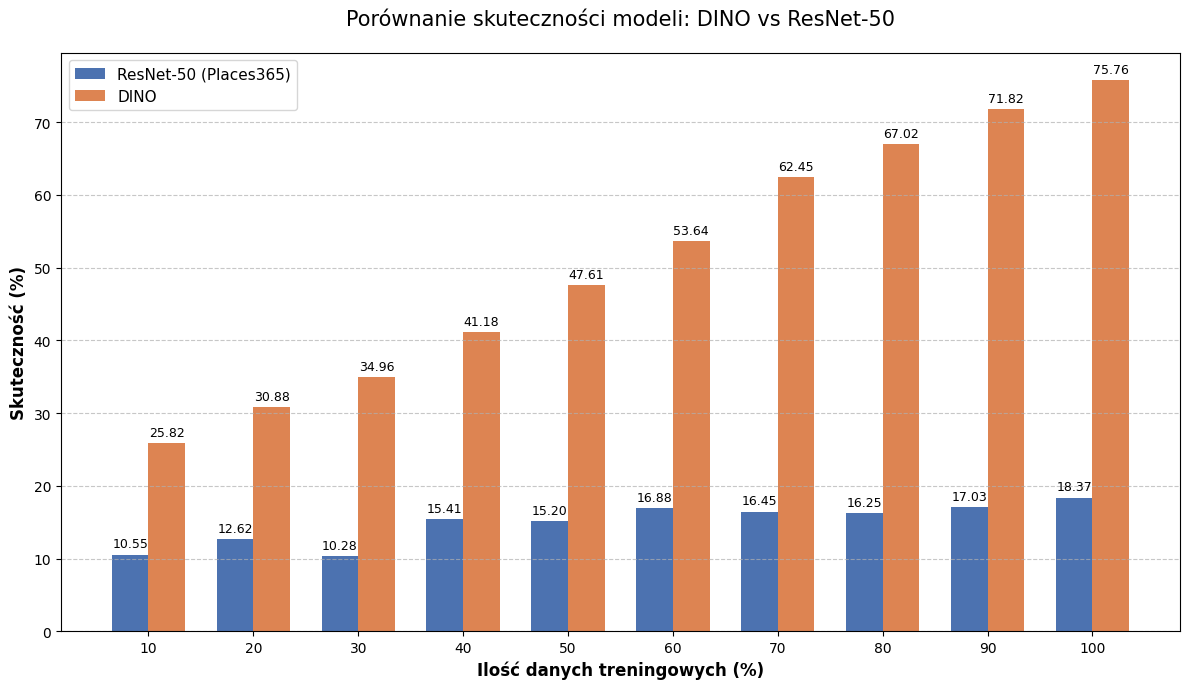

In [13]:
import matplotlib.pyplot as plt
import numpy as np

procent_danych = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]

resnet = [10.55, 12.62, 10.28, 15.41, 15.20, 16.88, 16.45, 16.25, 17.03, 18.37]

dino = [25.82, 30.88, 34.96, 41.18, 47.61, 53.64, 62.45, 67.02, 71.82, 75.76]

x = np.arange(len(procent_danych))  
szerokosc = 0.35

fig, ax = plt.subplots(figsize=(12, 7))

slupki_resnet = ax.bar(x - szerokosc/2, resnet, szerokosc, label='ResNet-50 (Places365)', color='#4C72B0')
slupki_dino = ax.bar(x + szerokosc/2, dino, szerokosc, label='DINO', color='#DD8452')

ax.set_xlabel('Ilość danych treningowych (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skuteczność (%)', fontsize=12, fontweight='bold')
ax.set_title('Porównanie skuteczności modeli: DINO vs ResNet-50', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(procent_danych)
ax.legend(fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)

def dodaj_etykiety(slupki):
    for slupek in slupki:
        wysokosc = slupek.get_height()
        ax.annotate(f'{wysokosc:.2f}',
                    xy=(slupek.get_x() + slupek.get_width() / 2, wysokosc),
                    xytext=(0, 3), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

dodaj_etykiety(slupki_resnet)
dodaj_etykiety(slupki_dino)

fig.tight_layout()

plt.savefig('plots/wykres_dino_vs_resnet.png', dpi=300)
plt.show()

Generowanie statystyk zbioru treningowego...
STATYSTYKI ZBIORU TRENINGOWEGO
Całkowita liczba zdjęć:  115846
Ilość unikalnych klas:   1000
Minimalna ilość zdjęć:   5 (w klasie)
Maksymalna ilość zdjęć:  1280 (w klasie)
Średnia ilość zdjęć:     115.85
Mediana ilości zdjęć:    73.00


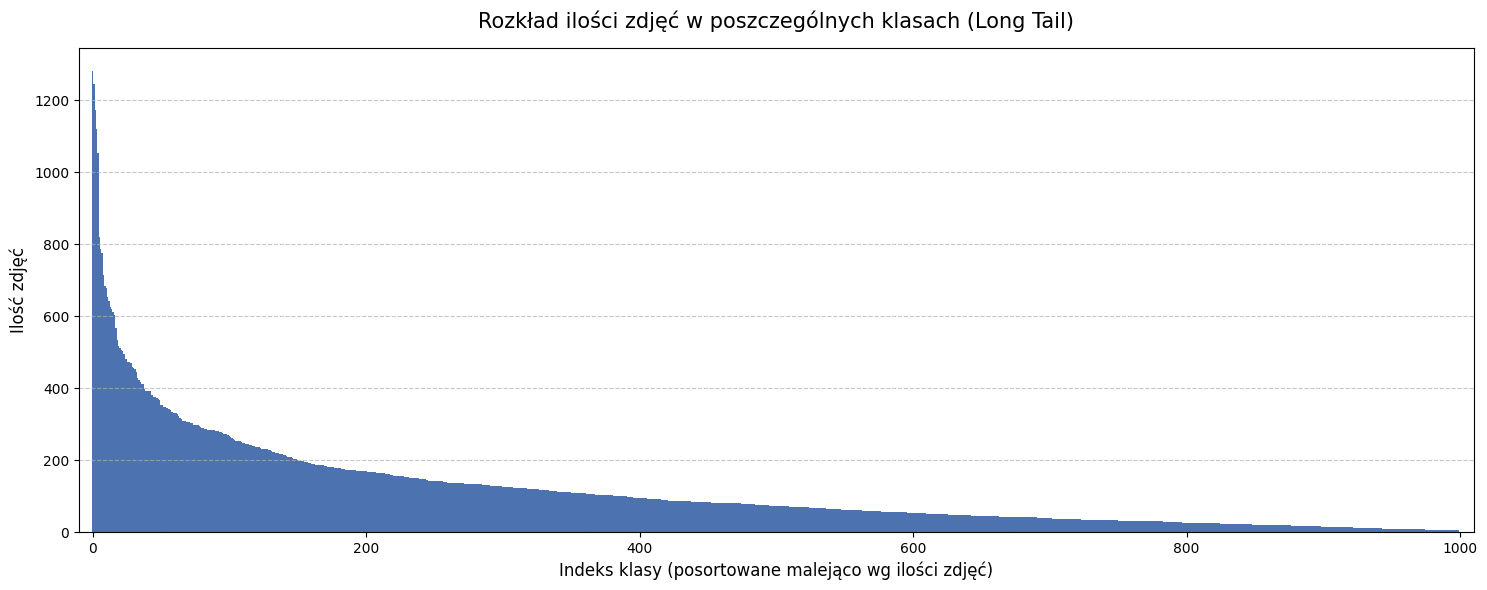

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter


print("Generowanie statystyk zbioru treningowego...")
train_labels = get_labels_safely(dataset["train"]).numpy()


class_counts = Counter(train_labels)


labels, counts = zip(*sorted(class_counts.items()))
counts_array = np.array(counts)

num_classes = len(labels)
total_images = np.sum(counts_array)
min_images = np.min(counts_array)
max_images = np.max(counts_array)
mean_images = np.mean(counts_array)
median_images = np.median(counts_array)

print(f"{'='*40}")
print(f"STATYSTYKI ZBIORU TRENINGOWEGO")
print(f"{'='*40}")
print(f"Całkowita liczba zdjęć:  {total_images}")
print(f"Ilość unikalnych klas:   {num_classes}")
print(f"Minimalna ilość zdjęć:   {min_images} (w klasie)")
print(f"Maksymalna ilość zdjęć:  {max_images} (w klasie)")
print(f"Średnia ilość zdjęć:     {mean_images:.2f}")
print(f"Mediana ilości zdjęć:    {median_images:.2f}")
print(f"{'='*40}\n")

plt.figure(figsize=(15, 6))

sorted_counts = sorted(counts, reverse=True)

plt.bar(range(num_classes), sorted_counts, color='#4C72B0', width=1.0)
plt.title('Rozkład ilości zdjęć w poszczególnych klasach (Long Tail)', fontsize=15, pad=15)
plt.xlabel('Indeks klasy (posortowane malejąco wg ilości zdjęć)', fontsize=12)
plt.ylabel('Ilość zdjęć', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.xlim(-10, num_classes + 10)
plt.tight_layout()

plt.show()

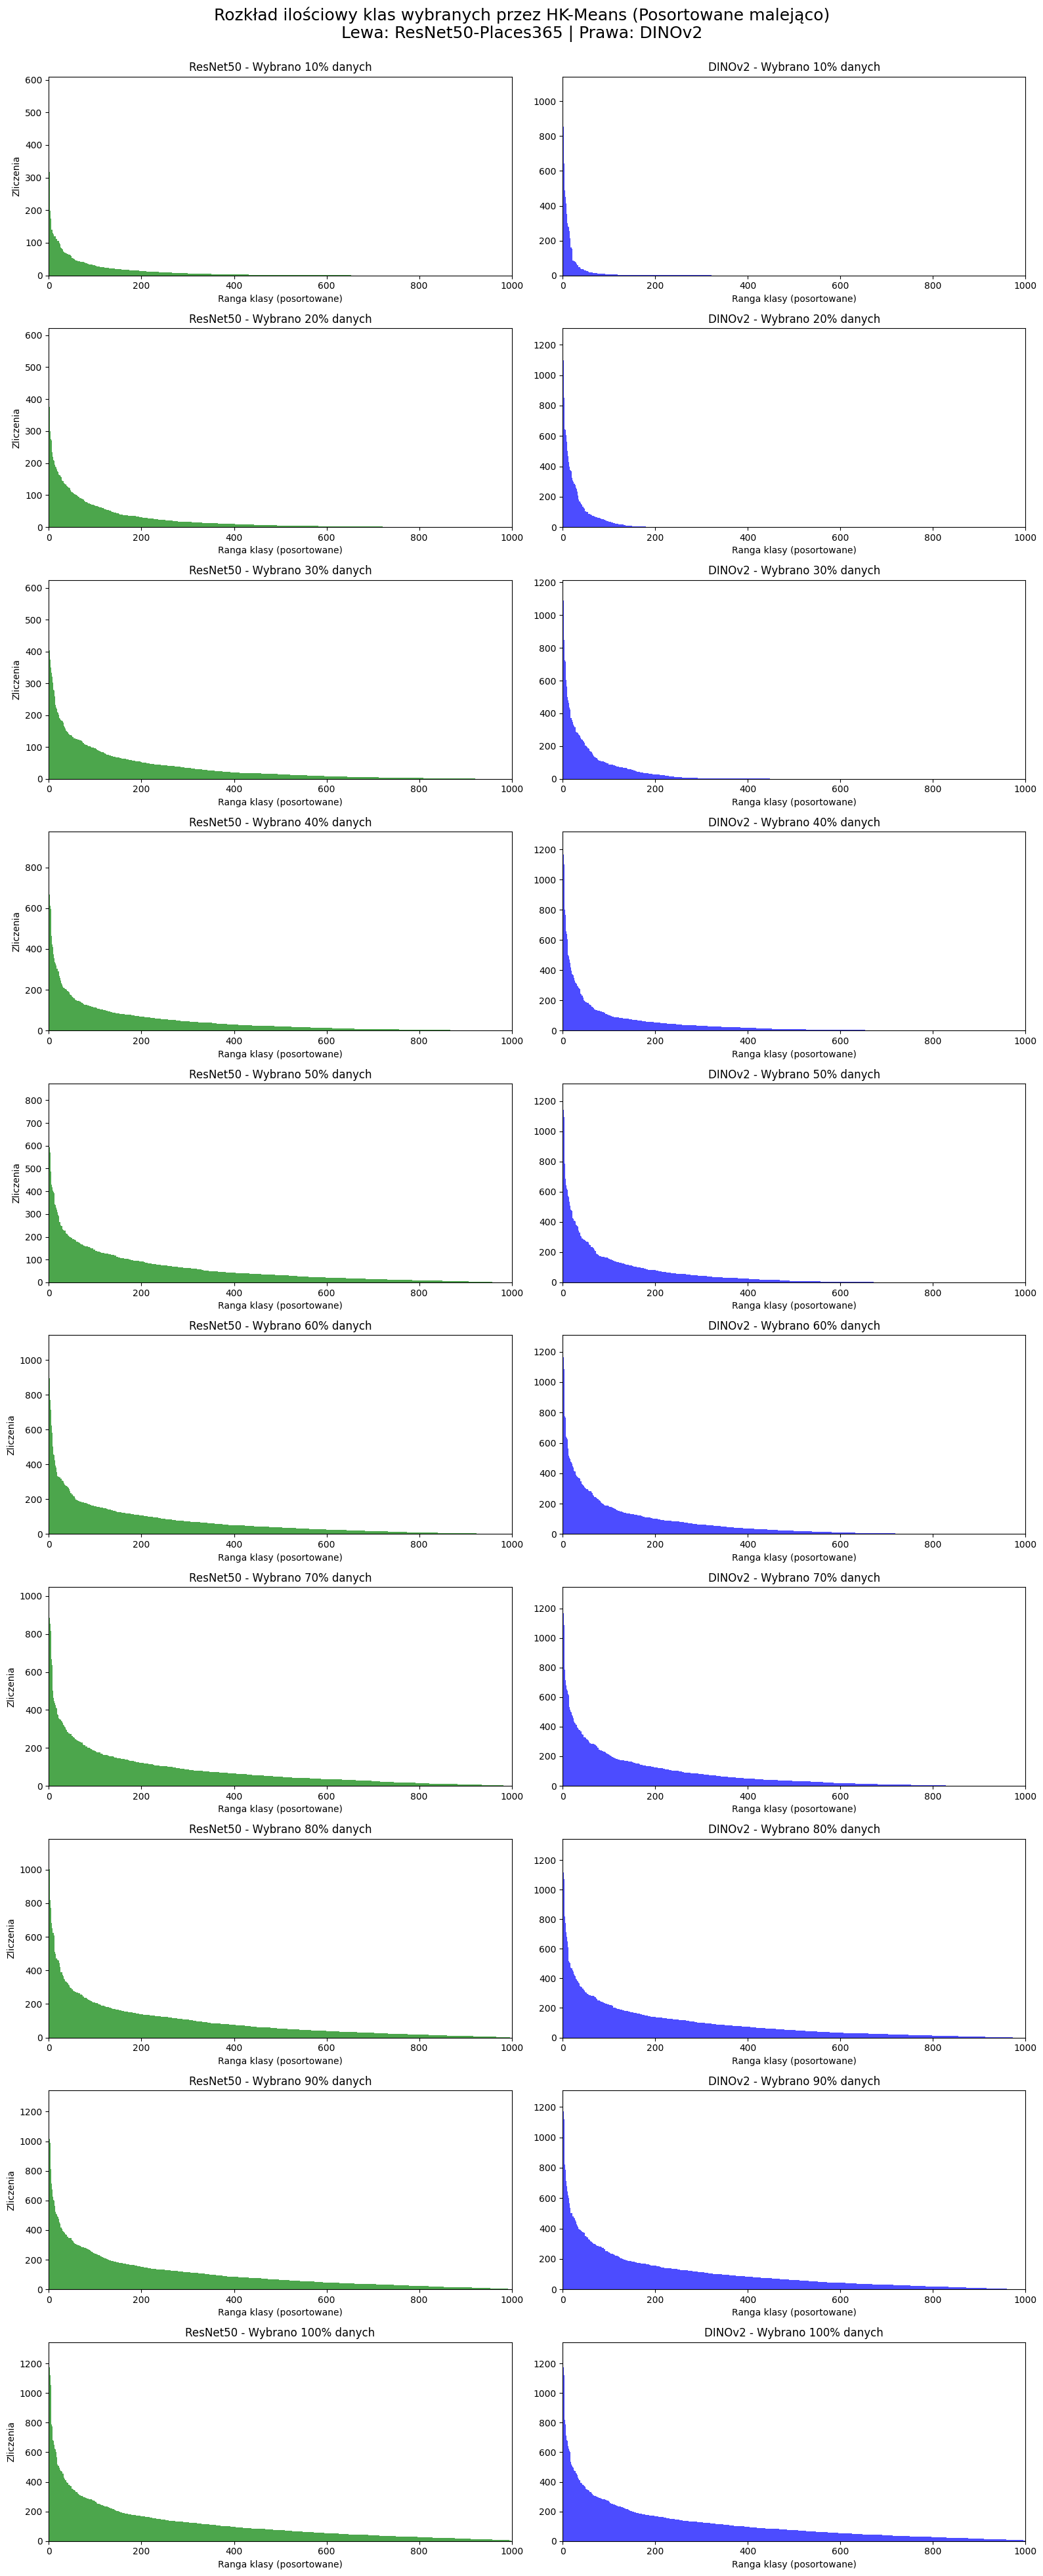

In [15]:
fig, axes = plt.subplots(len(percentages), 2, figsize=(16, 4 * len(percentages)))
fig.suptitle("Rozkład ilościowy klas wybranych przez HK-Means (Posortowane malejąco)\nLewa: ResNet50-Places365 | Prawa: DINOv2", fontsize=18)

for i, p in enumerate(percentages):

    labels_res = [train_labels[idx].item() for idx in history_resnet[p]]
    counts_res = Counter(labels_res)
    
    sorted_counts_res = sorted(counts_res.values(), reverse=True)
    
    ax_res = axes[i, 0] if len(percentages) > 1 else axes[0]
    ax_res.bar(range(len(sorted_counts_res)), sorted_counts_res, width=1.0, color='green', alpha=0.7)
    ax_res.set_title(f"ResNet50 - Wybrano {p}% danych")
    ax_res.set_ylabel("Zliczenia")
    ax_res.set_xlabel("Ranga klasy (posortowane)")
    ax_res.set_xlim(0, NUM_CLASSES)

    labels_din = [train_labels[idx].item() for idx in history_dino[p]]
    counts_din = Counter(labels_din)
    
    sorted_counts_din = sorted(counts_din.values(), reverse=True)
    
    ax_din = axes[i, 1] if len(percentages) > 1 else axes[1]
    ax_din.bar(range(len(sorted_counts_din)), sorted_counts_din, width=1.0, color='blue', alpha=0.7)
    ax_din.set_title(f"DINOv2 - Wybrano {p}% danych")
    ax_din.set_xlabel("Ranga klasy (posortowane)")
    ax_din.set_xlim(0, NUM_CLASSES)

plt.tight_layout(rect=[0, 0, 1, 0.98])

plt.savefig('plots/class_distribution_sorted.png', dpi=300)
plt.show()

In [16]:
total_train_samples = len(train_labels)

In [24]:
import pandas as pd


percentages_gs = [40, 60, 80]

grid_search_params = [

    {"n_levels": 2, "n_clusters": [100, 10]},
    {"n_levels": 2, "n_clusters": [50, 20]},
    {"n_levels": 2, "n_clusters": [200, 5]},
    {"n_levels": 2, "n_clusters": [10, 100]},
    {"n_levels": 2, "n_clusters": [32, 32]}, 

    {"n_levels": 3, "n_clusters": [10, 10, 10]}, 
    {"n_levels": 3, "n_clusters": [20, 10, 5]}, 
    {"n_levels": 3, "n_clusters": [5, 10, 20]}, 
    {"n_levels": 3, "n_clusters": [50, 4, 5]},
    {"n_levels": 3, "n_clusters": [100, 5, 2]}
]

results_gs = []

print("Rozpoczynam Grid Search dla hierarchicznego k-means...")

for p in percentages_gs:
    print(f"\n{'='*60}")
    print(f"GRID SEARCH: {p}% danych treningowych")
    print(f"{'='*60}")
    num_samples = int(total_train_samples * (p / 100.0))
    
    best_acc = 0
    best_config = None
    
    for idx, config in enumerate(grid_search_params):
        n_levels = config["n_levels"]
        n_clusters = config["n_clusters"]
        
        sz = [max(1, int(num_samples / n)) for n in n_clusters]
            
        print(f"[{idx+1}/{len(grid_search_params)}] Testuję: n_levels={n_levels}, n_clusters={n_clusters}, sz={sz}")
        
        set_seed(SEED)
        try:
            c_din = hkmg.hierarchical_kmeans_with_resampling(
                data=train_dino_emb.float(), 
                n_clusters=n_clusters, 
                n_levels=n_levels, 
                sample_sizes=sz, 
                verbose=False
            )
            
            cluster_obj_din = HierarchicalCluster.from_dict(c_din)

            idx_din = hs.hierarchical_sampling(
                clusters=cluster_obj_din, 
                target_size=num_samples, 
                sampling_strategy="c"
            ).astype(int).tolist()

            acc_dino, _ = train_linear_probing(
                train_dino_emb[idx_din].float(), train_labels[idx_din],
                val_dino_emb.float(), val_labels,
                test_dino_emb.float(), test_labels, 
                f"GS DINO {p}%",
                max_epochs=20, patience=3
            )
            
            print(f" ---> Dokładność: {acc_dino:.2f}%")
            results_gs.append({
                "Zbiór (%)": p,
                "Liczba poziomów": n_levels,
                "Układ klastrów": str(n_clusters),
                "Dokładność (%)": round(acc_dino, 2)
            })
            
            if acc_dino > best_acc:
                best_acc = acc_dino
                best_config = config
                
        except Exception as e:
            print(f" ---> Błąd przy tej konfiguracji (prawdopodobnie zbyt mało danych na sz): {e}")
            
    print(f"\nNAJLEPSZA KONFIGURACJA DLA {p}% DANYCH")
    print(f"n_levels: {best_config['n_levels']}, n_clusters: {best_config['n_clusters']} -> {best_acc:.2f}%\n")

df_gs = pd.DataFrame(results_gs)
df_gs = df_gs.sort_values(by=["Zbiór (%)", "Dokładność (%)"], ascending=[True, False]).reset_index(drop=True)

print("\nPełne wyniki Grid Search (posortowane malejąco wg dokładności dla każdego %):")
display(df_gs)

Rozpoczynam Grid Search dla hierarchicznego k-means...

GRID SEARCH: 40% danych treningowych
[1/10] Testuję: n_levels=2, n_clusters=[100, 10], sz=[463, 4633]
Hierarchical sampling from clusters: 100%|██████████| 10/10 [00:00<00:00, 2838.98it/s]
 ---> Błąd przy tej konfiguracji (prawdopodobnie zbyt mało danych na sz): 'int' object is not callable
[2/10] Testuję: n_levels=2, n_clusters=[50, 20], sz=[926, 2316]
Hierarchical sampling from clusters: 100%|██████████| 20/20 [00:00<00:00, 6308.65it/s]
 ---> Błąd przy tej konfiguracji (prawdopodobnie zbyt mało danych na sz): 'int' object is not callable
[3/10] Testuję: n_levels=2, n_clusters=[200, 5], sz=[231, 9267]
Hierarchical sampling from clusters: 100%|██████████| 5/5 [00:00<00:00, 811.50it/s]
 ---> Błąd przy tej konfiguracji (prawdopodobnie zbyt mało danych na sz): 'int' object is not callable
[4/10] Testuję: n_levels=2, n_clusters=[10, 100], sz=[4633, 463]
Hierarchical k-means resampling steps:   0%|          | 0/10 [00:00<?, ?it/s]
 ---

TypeError: 'NoneType' object is not subscriptable

In [ ]:
import pandas as pd

percentages_gs = [40, 60,70, 80]

total_train_samples = len(train_labels)
grid_search_params = [
    {"n_levels": 2, "n_clusters": [50, 20]},   
    {"n_levels": 2, "n_clusters": [20, 50]},   
    {"n_levels": 2, "n_clusters": [40, 25]},  
    {"n_levels": 2, "n_clusters": [25, 40]},  
    {"n_levels": 2, "n_clusters": [32, 32]},  
    {"n_levels": 2, "n_clusters": [10, 100]}, 
    {"n_levels": 2, "n_clusters": [100, 10]}, 
    {"n_levels": 2, "n_clusters": [25, 20]},   
    {"n_levels": 2, "n_clusters": [50, 40]},   
    {"n_levels": 2, "n_clusters": [100, 20]}, 

    # --- 3 POZIOMY ---
    {"n_levels": 3, "n_clusters": [20, 10, 5]}, 
    {"n_levels": 3, "n_clusters": [10, 20, 5]}, 
    {"n_levels": 3, "n_clusters": [5, 20, 10]},
    {"n_levels": 3, "n_clusters": [10, 10, 10]},
    {"n_levels": 3, "n_clusters": [5, 10, 20]},
    {"n_levels": 3, "n_clusters": [8, 11, 11]}, 
    {"n_levels": 3, "n_clusters": [25, 8, 5]},  
    {"n_levels": 3, "n_clusters": [5, 5, 40]},  
    {"n_levels": 3, "n_clusters": [40, 5, 5]},  
    {"n_levels": 3, "n_clusters": [10, 5, 10]}  
]

results_gs = []

print("Rozpoczynam Rozszerzony Grid Search dla hierarchicznego k-means...")

for p in percentages_gs:
    print(f"\n{'='*60}")
    print(f"GRID SEARCH: {p}% danych treningowych")
    print(f"{'='*60}")
    num_samples = int(total_train_samples * (p / 100.0))
    
    best_acc = 0
    best_config = None
    
    for idx, config in enumerate(grid_search_params):
        n_levels = config["n_levels"]
        n_clusters = config["n_clusters"]
        
        sz = [max(1, int(num_samples / n)) for n in n_clusters]
            
        print(f"[{idx+1}/{len(grid_search_params)}] Testuję: n_clusters={n_clusters}, sz={sz}")
        
        set_seed(SEED)
        try:
            c_din = hkmg.hierarchical_kmeans_with_resampling(
                data=train_dino_emb.float(), 
                n_clusters=n_clusters, 
                n_levels=n_levels, 
                sample_sizes=sz, 
                verbose=False
            )
            
            cluster_obj_din = HierarchicalCluster.from_dict(c_din)
            
            idx_din = hs.hierarchical_sampling(
                clusters=cluster_obj_din, 
                target_size=num_samples, 
                sampling_strategy="c"
            ).astype(int).tolist()
            

            acc_dino, _ = train_linear_probing(
                train_dino_emb[idx_din].float(), train_labels[idx_din],
                val_dino_emb.float(), val_labels,
                test_dino_emb.float(), test_labels, 
                f"GS DINO {p}%",
                max_epochs=20, patience=3
            )
            
            print(f" ---> Dokładność: {acc_dino:.2f}%")
            
            results_gs.append({
                "Zbiór (%)": p,
                "Liczba poziomów": n_levels,
                "Układ klastrów": str(n_clusters),
                "Dokładność (%)": round(acc_dino, 2)
            })
            
            if acc_dino > best_acc:
                best_acc = acc_dino
                best_config = config
                
        except Exception as e:
            print(f" ---> Błąd przy tej konfiguracji: {e}")
            
    if best_config:
        print(f"\nNAJLEPSZA KONFIGURACJA DLA {p}% DANYCH")
        print(f"Układ klastrów: {best_config['n_clusters']} -> {best_acc:.2f}%\n")
    
df_gs = pd.DataFrame(results_gs)
df_gs = df_gs.sort_values(by=["Zbiór (%)", "Dokładność (%)"], ascending=[True, False]).reset_index(drop=True)

print("\nPełne wyniki Rozszerzonego Grid Search (posortowane malejąco):")
display(df_gs)

In [23]:
import random
import numpy as np
import torch

RANDOM_SEEDS = [SEED, 42, 1234, 9999, 65] 

results_random_resnet_mean = []
results_random_resnet_std = []
results_random_dino_mean = []
results_random_dino_std = []

print(f"Rozpoczynam testowanie losowego próbkowania (uśrednione z {len(RANDOM_SEEDS)} seedów)...")

for p in percentages:
    print(f"\n{'='*40}\nEksperyment Random: {p}% danych treningowych\n{'='*40}")
    num_samples = int(total_train_samples * (p / 100.0))
    
    if p == 100:
        idx_random = list(range(total_train_samples))
        
        acc_resnet_rand, _ = train_linear_probing(
            train_resnet_emb[idx_random].float(), torch.as_tensor(train_labels)[idx_random],
            val_resnet_emb.float(), val_labels,
            test_resnet_emb.float(), test_labels, f"Random ResNet {p}%"
        )

        acc_dino_rand, _ = train_linear_probing(
            train_dino_emb[idx_random].float(), torch.as_tensor(train_labels)[idx_random],
            val_dino_emb.float(), val_labels,
            test_dino_emb.float(), test_labels, f"Random DINO {p}%"
        )
        
        results_random_resnet_mean.append(acc_resnet_rand)
        results_random_resnet_std.append(0.0)
        results_random_dino_mean.append(acc_dino_rand)
        results_random_dino_std.append(0.0)
        
        print(f"Random (100%) -> ResNet-50: {acc_resnet_rand:.2f}% | DINO: {acc_dino_rand:.2f}%")
        
    else:
        temp_acc_resnet = []
        temp_acc_dino = []
        
        for idx, s in enumerate(RANDOM_SEEDS, 1):
            set_seed(s) 
            idx_random = random.sample(range(total_train_samples), num_samples)
            
            acc_resnet_rand, _ = train_linear_probing(
                train_resnet_emb[idx_random].float(), torch.as_tensor(train_labels)[idx_random],
                val_resnet_emb.float(), val_labels,
                test_resnet_emb.float(), test_labels, f"Random ResNet {p}% (seed {s})"
            )

            acc_dino_rand, _ = train_linear_probing(
                train_dino_emb[idx_random].float(), torch.as_tensor(train_labels)[idx_random],
                val_dino_emb.float(), val_labels,
                test_dino_emb.float(), test_labels, f"Random DINO {p}% (seed {s})"
            )
            
            temp_acc_resnet.append(acc_resnet_rand)
            temp_acc_dino.append(acc_dino_rand)
            
            # Wypisywanie wyniku natychmiast po skończeniu danego seeda
            print(f" ---> [{idx}/{len(RANDOM_SEEDS)}] Ukończono seed {s} | ResNet: {acc_resnet_rand:.2f}% | DINO: {acc_dino_rand:.2f}%")
            
        avg_resnet = np.mean(temp_acc_resnet)
        std_resnet = np.std(temp_acc_resnet)
        
        avg_dino = np.mean(temp_acc_dino)
        std_dino = np.std(temp_acc_dino)
        
        results_random_resnet_mean.append(avg_resnet)
        results_random_resnet_std.append(std_resnet)
        
        results_random_dino_mean.append(avg_dino)
        results_random_dino_std.append(std_dino)
        
        print(f"\n[PODSUMOWANIE {p}%] Random -> ResNet-50: {avg_resnet:.2f}% (±{std_resnet:.2f}) | DINO: {avg_dino:.2f}% (±{std_dino:.2f})")

Rozpoczynam testowanie losowego próbkowania (uśrednione z 5 seedów)...

Eksperyment Random: 10% danych treningowych
 ---> [1/5] Ukończono seed 45390 | ResNet: 13.91% | DINO: 70.16%
 ---> [2/5] Ukończono seed 42 | ResNet: 14.06% | DINO: 70.67%
 ---> [3/5] Ukończono seed 1234 | ResNet: 14.10% | DINO: 70.25%
 ---> [4/5] Ukończono seed 9999 | ResNet: 13.83% | DINO: 69.18%
 ---> [5/5] Ukończono seed 65 | ResNet: 14.17% | DINO: 70.31%

[PODSUMOWANIE 10%] Random -> ResNet-50: 14.01% (±0.13) | DINO: 70.11% (±0.50)

Eksperyment Random: 20% danych treningowych
 ---> [1/5] Ukończono seed 45390 | ResNet: 16.15% | DINO: 73.72%
 ---> [2/5] Ukończono seed 42 | ResNet: 15.73% | DINO: 74.10%
 ---> [3/5] Ukończono seed 1234 | ResNet: 14.84% | DINO: 74.06%
 ---> [4/5] Ukończono seed 9999 | ResNet: 14.97% | DINO: 73.73%
 ---> [5/5] Ukończono seed 65 | ResNet: 15.79% | DINO: 74.51%

[PODSUMOWANIE 20%] Random -> ResNet-50: 15.50% (±0.51) | DINO: 74.03% (±0.29)

Eksperyment Random: 30% danych treningowych
 -

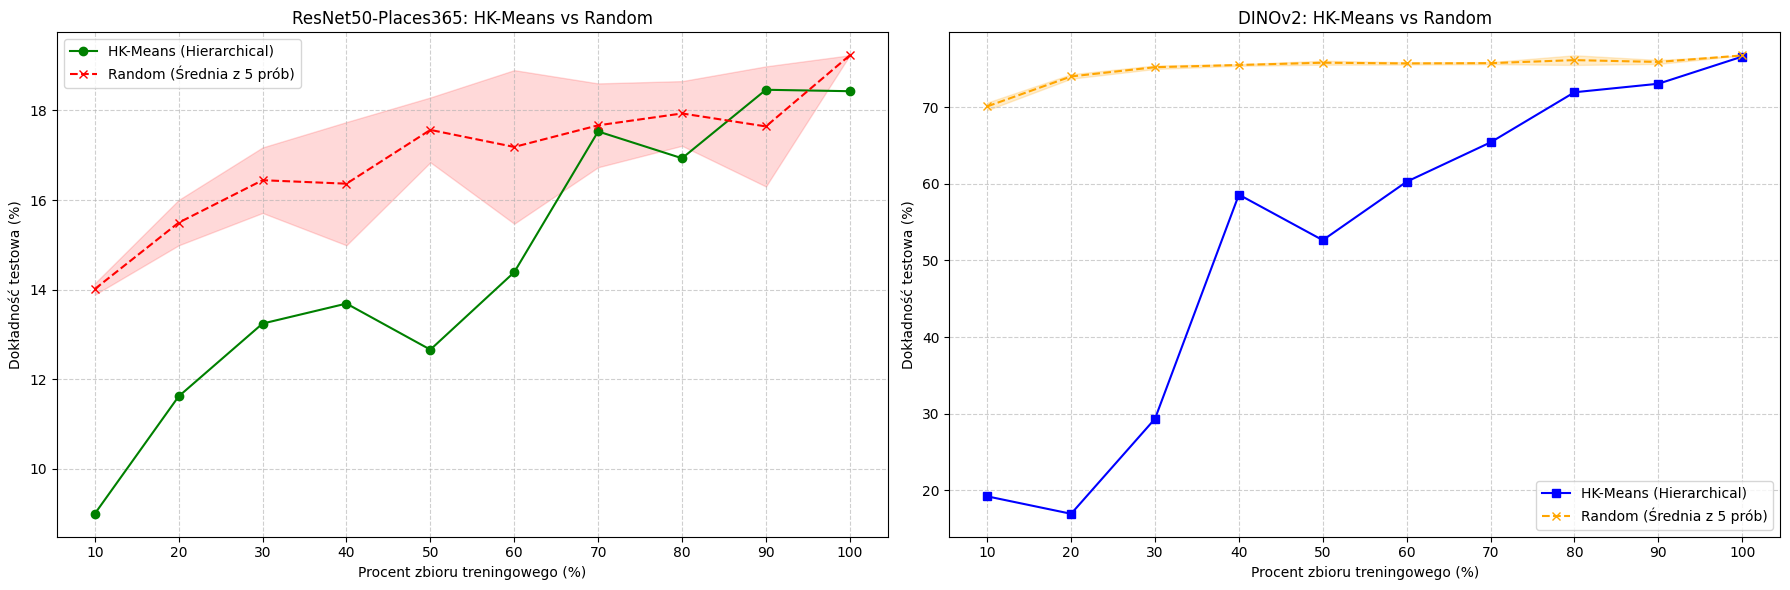

In [25]:
import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

perc_arr = np.array(percentages)
rand_res_mean = np.array(results_random_resnet_mean)
rand_res_std = np.array(results_random_resnet_std)
rand_din_mean = np.array(results_random_dino_mean)
rand_din_std = np.array(results_random_dino_std)

ax1.plot(percentages, results_resnet, marker='o', color='green', label='HK-Means (Hierarchical)')
ax1.plot(percentages, rand_res_mean, marker='x', color='red', linestyle='--', label=f'Random (Średnia z {len(RANDOM_SEEDS)} prób)')

ax1.fill_between(perc_arr, rand_res_mean - rand_res_std, rand_res_mean + rand_res_std, color='red', alpha=0.15)

ax1.set_title('ResNet50-Places365: HK-Means vs Random')
ax1.set_xlabel('Procent zbioru treningowego (%)')
ax1.set_ylabel('Dokładność testowa (%)')
ax1.set_xticks(percentages)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


ax2.plot(percentages, results_dino, marker='s', color='blue', label='HK-Means (Hierarchical)')
ax2.plot(percentages, rand_din_mean, marker='x', color='orange', linestyle='--', label=f'Random (Średnia z {len(RANDOM_SEEDS)} prób)')

ax2.fill_between(perc_arr, rand_din_mean - rand_din_std, rand_din_mean + rand_din_std, color='orange', alpha=0.2)

ax2.set_title('DINOv2: HK-Means vs Random')
ax2.set_xlabel('Procent zbioru treningowego (%)')
ax2.set_ylabel('Dokładność testowa (%)')
ax2.set_xticks(percentages)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('plots/hkmeans_vs_random_lineplot_std.png', dpi=300)
plt.show()

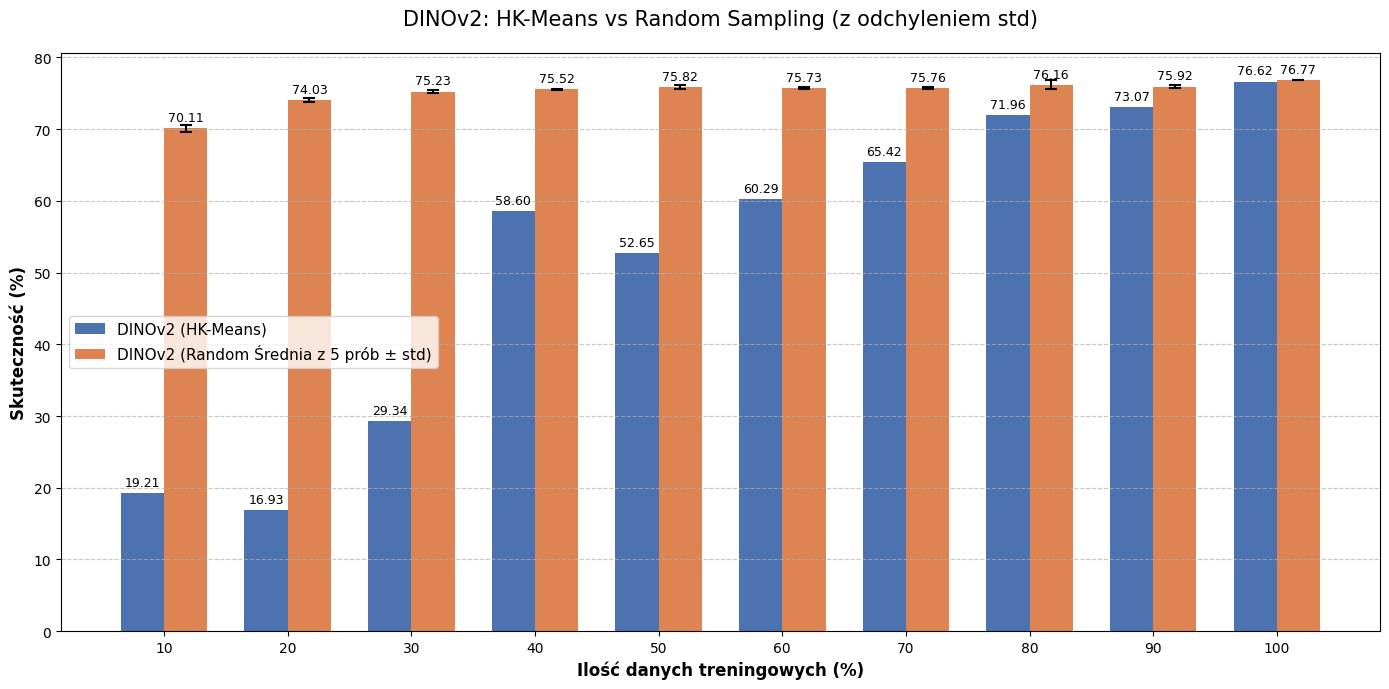

In [26]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(percentages))  
szerokosc = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

slupki_hk_din = ax.bar(x - szerokosc/2, results_dino, szerokosc, label='DINOv2 (HK-Means)', color='#4C72B0')


slupki_rand_din = ax.bar(
    x + szerokosc/2, 
    results_random_dino_mean, 
    szerokosc, 
    yerr=results_random_dino_std,
    capsize=4,
    error_kw=dict(lw=1.5, capthick=1.5, color='black'),
    label=f'DINOv2 (Random Średnia z {len(RANDOM_SEEDS)} prób ± std)', 
    color='#DD8452'
)

ax.set_xlabel('Ilość danych treningowych (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skuteczność (%)', fontsize=12, fontweight='bold')
ax.set_title('DINOv2: HK-Means vs Random Sampling (z odchyleniem std)', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(percentages)
ax.legend(fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)

dodaj_etykiety(slupki_hk_din)
dodaj_etykiety(slupki_rand_din)

fig.tight_layout()
plt.savefig('plots/wykres_dino_hk_vs_random_bar_std.png', dpi=300)
plt.show()

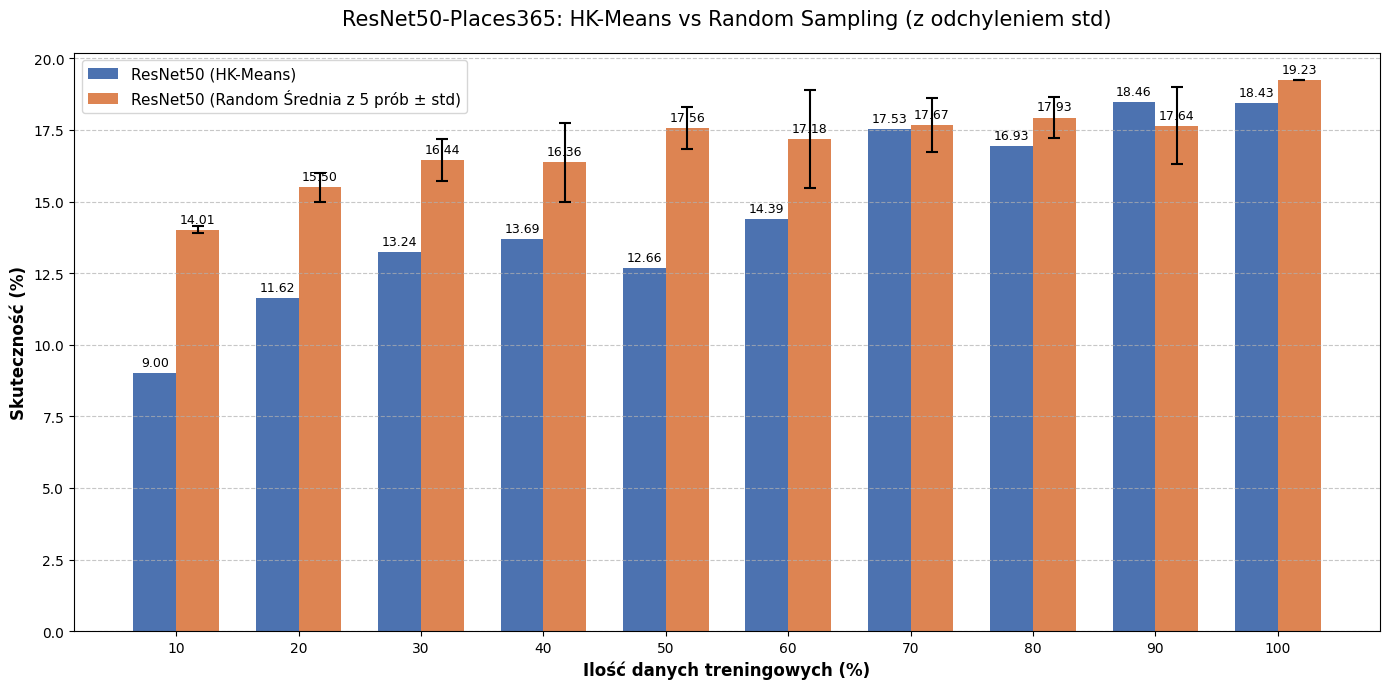

In [27]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(percentages))  
szerokosc = 0.35

fig, ax = plt.subplots(figsize=(14, 7))

slupki_hk_res = ax.bar(x - szerokosc/2, results_resnet, szerokosc, label='ResNet50 (HK-Means)', color='#4C72B0')
slupki_rand_res = ax.bar(
    x + szerokosc/2, 
    results_random_resnet_mean, 
    szerokosc, 
    yerr=results_random_resnet_std,
    capsize=4,
    error_kw=dict(lw=1.5, capthick=1.5, color='black'),
    label=f'ResNet50 (Random Średnia z {len(RANDOM_SEEDS)} prób ± std)', 
    color='#DD8452'
)

ax.set_xlabel('Ilość danych treningowych (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Skuteczność (%)', fontsize=12, fontweight='bold')
ax.set_title('ResNet50-Places365: HK-Means vs Random Sampling (z odchyleniem std)', fontsize=15, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(percentages)
ax.legend(fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.7)

dodaj_etykiety(slupki_hk_res)
dodaj_etykiety(slupki_rand_res)

fig.tight_layout()
plt.savefig('plots/wykres_resnet_hk_vs_random_bar_std.png', dpi=300)
plt.show()

Generowanie statystyk zbioru walidacyjnego i testowego dla ImageNet-LT...


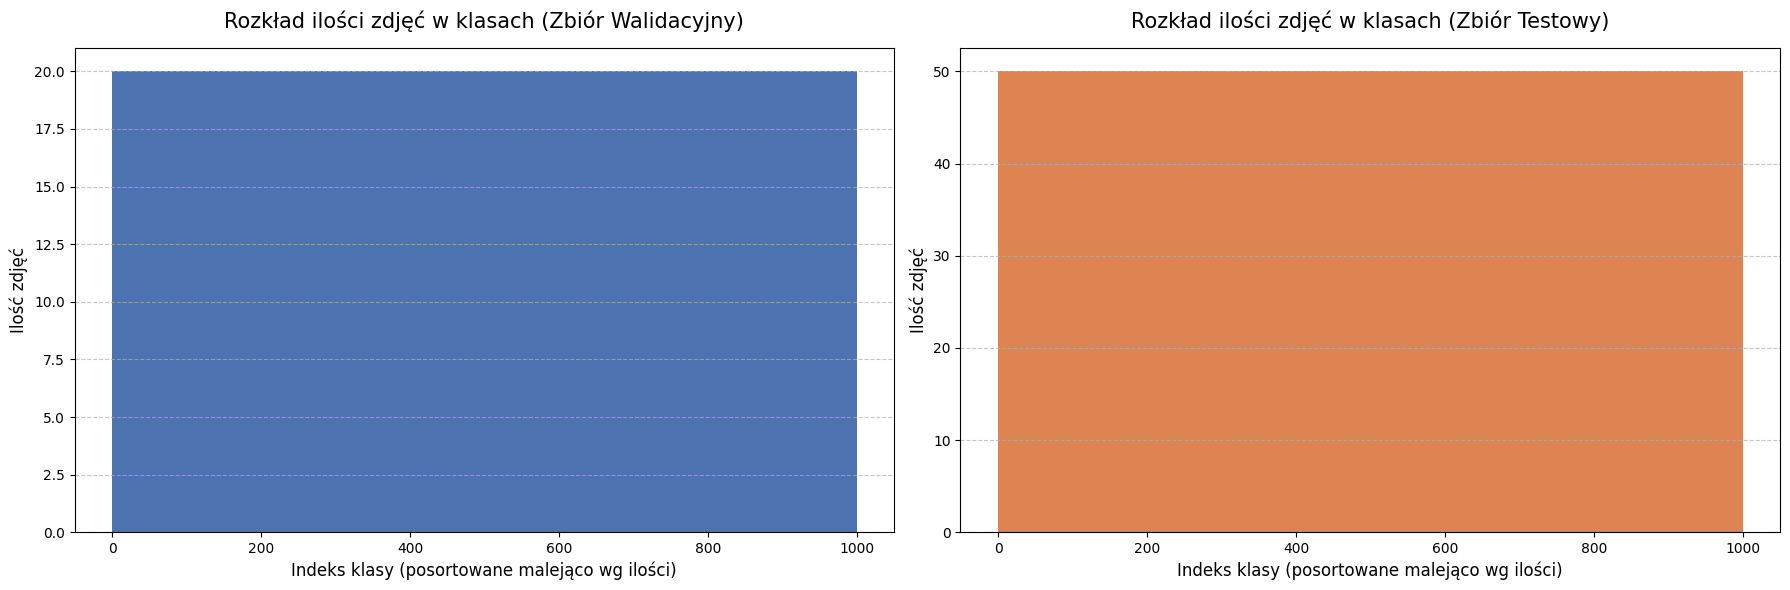

In [8]:
print("Generowanie statystyk zbioru walidacyjnego i testowego dla ImageNet-LT...")

val_class_counts = Counter(val_labels.numpy())
test_class_counts = Counter(test_labels.numpy())

v_labels, v_counts = zip(*sorted(val_class_counts.items(), key=lambda x: x[1], reverse=True))
t_labels, t_counts = zip(*sorted(test_class_counts.items(), key=lambda x: x[1], reverse=True))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
ax1.bar(range(len(v_labels)), v_counts, color='#4C72B0', width=1.0)
ax1.set_title('Rozkład ilości zdjęć w klasach (Zbiór Walidacyjny)', fontsize=15, pad=15)
ax1.set_xlabel('Indeks klasy (posortowane malejąco wg ilości)', fontsize=12)
ax1.set_ylabel('Ilość zdjęć', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

ax2.bar(range(len(t_labels)), t_counts, color='#DD8452', width=1.0)
ax2.set_title('Rozkład ilości zdjęć w klasach (Zbiór Testowy)', fontsize=15, pad=15)
ax2.set_xlabel('Indeks klasy (posortowane malejąco wg ilości)', fontsize=12)
ax2.set_ylabel('Ilość zdjęć', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.savefig('plots/val_test_distribution.png', dpi=300)
plt.show()